In [ ]:
# 이전 강의
# 만약 두개의 문자를 고려해서 예측을 한다면 27 * 27 개의 확률들이 필요함. 3개면 27^3 ... => 매트릭스로는 너무 많음. 
# 오늘은 Multi Layer Perceptron 모델을 implement
# 논문에서
# 17,000개의 단어를 30(60 or 100) 차원의 feature vector로 임베딩
# 처음엔 랜덤 점점 백프롭으로 단어 임베딩을 tune. 단어 임베딩들의 포인트들은 공간에서 돌아다니면서 비슷한 의미의 단어는 비슷한 공간에 위치하고 의미가 다르면 다른 공간에.
# trainig 데이터의 log likelihood를 최대화하도록

# A dog was running in a [   ] 예측하려하고 "A dog was running in a" 가 정확히 학습 데이터 상에 나오지 않았다면
# 이 빈칸을 예측하려하는건 분포에서 벗어나게 됨. 학습 데이터 상에 나타나지 않았으므로 예측할 근거가 없음.
# 하지만 이 방법은 우회할 수 있게 해줌.
# 정확히 "A dog was running in a" 라는 문장을 보지 않았더라도 데이터에서 비슷한 문장을 보았을 것임. 
# 예를 들어 "The dog was running in a [  ]" 라던지.. 그래서 네트워크가 A 와 The가 자주 교환 가능함을 배울 수 있음.
# A의 임베딩과 The의 임베딩을 공간상에 가깝게 두어 임베딩을 통해 tranfer knowledge. 그리고 그 방법으로 generalize 가능.
# 비슷하게 cat 과 dog가 비슷한 컨텍스트 내에서 동일하게 등장함을 알거나 walking 이나 running도 마찬가지로 ,,
# Embedding space를 통해서 tranfer knowledge 가능 -> generalize

In [ ]:
# 논문 다이어그램 설명

# 3개의 이전 단어를 가지고 4번째 단어 예측하려함
# 각 3개의 단어마다 0부터 16,999 사이의 정수 인덱스를 가지고 이걸 입력 
# C라는 17,000 * 30 크기의 lookup table 존재. 단어의 인덱스가 들어가면 그것에 대응하는 임베딩 벡터를 뽑아냄.
# 여기서는 그러면 3개의 단어마다 30개의 뉴런을 가진 input 레이어(90개 뉴런)가 생김. C는 모든 단어들마다 같은 파라미터로 공유.

# 그다음으로 hidden layer로 들어감.
# hidden layer의 사이즈는 hyperparameter 
# 이것은 이전의 90개 뉴런과 fully connected 
# 마지막엔 tanh 

# 다음으로 output layer 
# 다음 단어로 17,000개의 단어가 올 수 있기 때문에 이 레이어는 17,000개의 뉴런이 존재하고 이전 레이어에 fully connected
# 단어가 파라미터가 많아지면서 가장 많이 연산을 잡아먹음.
# 17,000 로짓을 가지고 다음으로 softmax 연산 -> 다음 단어에 대한 확률 분포를 가지게 됨.
# 학습 중에는 라벨이 존재하므로 다음 단어가 무엇인지 있음. 그걸 가지고 해당 단어의 확률을 뽑아내서 해당 확률을 maximize 하도록 함. 네트워크의 파라미터에 대해서. 
# 파라미터는 output layer, hidden layer의 weights and biases, 그리고 lookup table C.
# 모든 것은 backprop을 이용해 조정 

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# read in all the words
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build a vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [99]:
# build the dataset 

block_size = 3 # context length: how many chars do we take to predict the next one?
X, Y = [], [] # X: input to the NN, Y: labels
for w in words: 
# for w in words[:5]: # 우선 5개 단어로

    # print(w)
    context = [0] * block_size # padded context로 시작. zero tokens
    for ch in w + '.':
        ix = stoi[ch] # 단어내 문자를 얻고
        X.append(context) # 현재 context 
        Y.append(ix)  # 현재 단어 
        # 한 단어에서 생성할 수 있는 예시 출력
        # ...라는 context에서는 label이 e, ..e context에서는 에서는 m
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append. 하나 짜르고 새로운 문자 넣어서 새로운 다음 context

X = torch.tensor(X)
Y = torch.tensor(Y)

In [11]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [169]:
# build dataset

def build_dataset(words):
    block_size = 3
    X, Y = [], [] 
    for w in words: 

        # print(w)
        context = [0] * block_size 
        for ch in w + '.':
            ix = stoi[ch] 
            X.append(context) 
            Y.append(ix)  
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append.

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [12]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [13]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [14]:
# lookup table C 만들기
# 논문에서는 17,000개의 단어에 30 임베딩 벡터
# 우리는 27 글자에 더 작은 차원으로 ex 2차원 으로

C = torch.randn((27,2))
C

tensor([[-0.3776, -0.1085],
        [ 0.1753, -1.2418],
        [ 0.1360,  1.5973],
        [ 0.3837, -0.3572],
        [ 0.1902, -0.1753],
        [-0.1400, -1.7025],
        [ 0.3186,  0.4538],
        [-0.2339, -1.1624],
        [ 0.2157,  0.3443],
        [ 1.0888,  0.0456],
        [ 0.8063, -0.0207],
        [-0.3629, -0.6066],
        [ 0.1747, -0.5583],
        [-0.1449,  0.3399],
        [-0.5541,  0.2086],
        [ 0.6475, -0.5798],
        [ 0.3808,  0.1976],
        [-0.7431,  0.4456],
        [ 0.7605, -0.2248],
        [ 0.3955,  1.1584],
        [-1.2798,  0.1612],
        [-1.0073,  0.2623],
        [-0.4905,  0.3062],
        [ 0.1714,  1.2772],
        [-0.3620,  1.0525],
        [ 0.0538, -0.2619],
        [-0.8160, -0.7103]])

In [15]:
C[5]

tensor([-0.1400, -1.7025])

In [19]:
F.one_hot(torch.tensor(5), num_classes=27) # 5가 아니라 tensor로 바꿔줘야 함. 
F.one_hot(torch.tensor(5), num_classes=27).float() @ C # C는 float이고 앞은 int64여서 변환필요. 곱하게되면 5번째만 뽑히게 됨. 위의 C[5]와 같은 동작. 위가 더 빠르므로 저거 사용

tensor([-0.1400, -1.7025])

In [24]:
# 그냥 인덱스 5에 대해서 뽑는 것은 쉽지만 32 * 3 크기의 X는 어떻게 임베딩하나?
C[X] # torch에선 그냥 지원함 

tensor([[[-0.3776, -0.1085],
         [-0.3776, -0.1085],
         [-0.3776, -0.1085]],

        [[-0.3776, -0.1085],
         [-0.3776, -0.1085],
         [-0.1400, -1.7025]],

        [[-0.3776, -0.1085],
         [-0.1400, -1.7025],
         [-0.1449,  0.3399]],

        [[-0.1400, -1.7025],
         [-0.1449,  0.3399],
         [-0.1449,  0.3399]],

        [[-0.1449,  0.3399],
         [-0.1449,  0.3399],
         [ 0.1753, -1.2418]],

        [[-0.3776, -0.1085],
         [-0.3776, -0.1085],
         [-0.3776, -0.1085]],

        [[-0.3776, -0.1085],
         [-0.3776, -0.1085],
         [ 0.6475, -0.5798]],

        [[-0.3776, -0.1085],
         [ 0.6475, -0.5798],
         [ 0.1747, -0.5583]],

        [[ 0.6475, -0.5798],
         [ 0.1747, -0.5583],
         [ 1.0888,  0.0456]],

        [[ 0.1747, -0.5583],
         [ 1.0888,  0.0456],
         [-0.4905,  0.3062]],

        [[ 1.0888,  0.0456],
         [-0.4905,  0.3062],
         [ 1.0888,  0.0456]],

        [[-0.4905,  0

In [ ]:
C[X].shape # 모든 32 x 3 정수마다 2개의 임베딩 벡터를 가져옴

torch.Size([32, 3, 2])

In [27]:
X[13,2]

tensor(1)

In [28]:
C[X][13,2]

tensor([ 0.1753, -1.2418])

In [29]:
C[1]

tensor([ 0.1753, -1.2418])

In [30]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [31]:
# hidden layer
W1 = torch.randn((6, 100)) # 3개 단어에 대해서 2개씩의 임베딩이 있으므로 6, 다음 크기는 우리 맘대로 
b1 = torch.randn(100)

In [ ]:
# emb @ W1 + b1 => emb가 32, 3, 2 사이즈라 안됨 32, 6으로 만들어야함
emb[:, 0, :].shape, emb[:, 1, :].shape, emb[:, 2, :].shape # => 얘네를 합치고 싶음
torch.cat([emb[:, 0, :],emb[:, 1, :],emb[:, 2, :]], 1).shape # -> [32, 6] but, code가 general하지 않음
torch.unbind(emb, 1)
torch.cat(torch.unbind(emb, 1), 1).shape # 요롷고롬. but, cat하기 위해 텐서를 복제하므로 메모리 더 사용. 더 좋은 방법이 있음. 아래에서,,

torch.Size([32, 6])

In [47]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [48]:
a.shape

torch.Size([18])

In [ ]:
a.view(9, 2) # [18]을 [9,2]로

tensor([[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17]])

In [51]:
a.storage() # .view를 부르더라도 a의 storage는 그대로 

 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [53]:
emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [64]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # hard coding 말고 emb.shape[0] or -1
h

tensor([[-0.0943, -0.8297, -0.3926,  ..., -0.8438,  0.7900,  0.4911],
        [ 0.0614,  0.3694, -0.8175,  ...,  0.7018,  0.9466,  0.4087],
        [ 0.6644,  0.8785, -0.8267,  ..., -0.9952,  0.9996,  0.3141],
        ...,
        [ 0.2394, -0.8618, -0.5435,  ..., -0.7619,  0.3814, -0.5483],
        [ 0.8934, -0.1865, -0.9361,  ...,  0.0792,  0.5626, -0.9738],
        [-0.0427,  0.7199, -0.4161,  ...,  0.8100,  0.9551, -0.9338]])

In [65]:
h.shape

torch.Size([32, 100])

In [66]:
(emb.view(-1, 6) @ W1).shape, b1.shape
# 32, 100   - >  32, 100
#     100   - >   1, 100 -> 32개 복제되어서 더해짐

(torch.Size([32, 100]), torch.Size([100]))

In [67]:
# output layer
W2 = torch.randn((100, 27)) 
b2 = torch.randn(27)

In [69]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [70]:
counts = logits.exp()

In [71]:
prob = counts / counts.sum(1, keepdim=True)

In [73]:
prob.shape

torch.Size([32, 27])

In [75]:
prob[0].sum()

tensor(1.)

In [77]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [79]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(12.9933)

In [80]:
# -------------------- now mad respectable -------------------

In [170]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [225]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g) # embedding size 2 -> 10
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [226]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [227]:
for p in parameters:
    p.requires_grad = True

In [228]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [229]:
lri = []
lossi = []
stepi = []

In [ ]:
for i in range(200000):
    # minibatch construct. minibatch라 grad가 완전히 믿을만하진않지만 good enough
    # approx grad로 많은 스텝을 하는 것이 정확한 grad로 적은 스텝을 가는 것보다 낫다
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2), ix의 문자만(minibatch)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix]) # => 위 과정과 같지만 더 효율적
    # print(loss.item())  

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())


KeyboardInterrupt: 

In [236]:
# sample from the model 
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

chriah.
quille.
khyimli.
rehay.
halayan.
jazine.
farlyah.
jageri.
nelynn.
jaymiir.
kaleigh.
ham.
joci.
quinn.
shlyn.
mila.
bicia.
ell.
diarysi.
jaydeni.


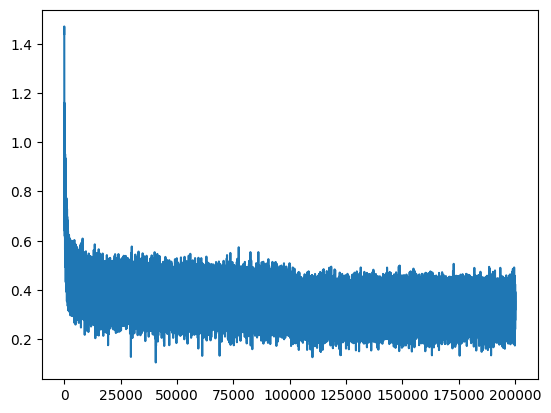

In [231]:
plt.plot(stepi, lossi)

In [232]:
# training loss
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss # minibatch 학습 결과를 전체 데이터셋에 데해서 loss 측정

tensor(2.1383, grad_fn=<NllLossBackward0>)

In [ ]:
# validation loss
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss # minibatch 학습 결과를 전체 데이터셋에 데해서 loss 측정

tensor(2.1737, grad_fn=<NllLossBackward0>)

In [237]:
# test loss
emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss # minibatch 학습 결과를 전체 데이터셋에 데해서 loss 측정

tensor(2.3108, grad_fn=<NllLossBackward0>)

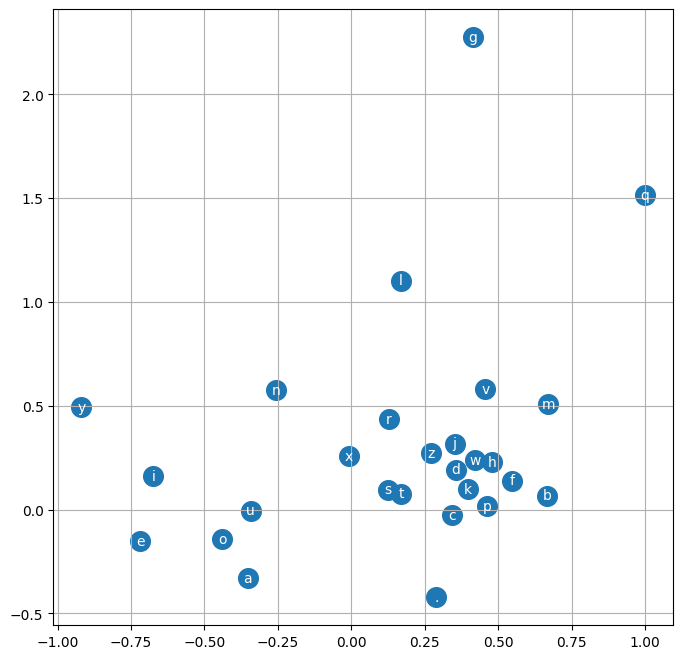

In [207]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')
# 문자들로 train한 모델이 뱉은 임베딩 출력
# a i e o u 들이 모여있음. 비슷하고 교환 가능하다고 생각함

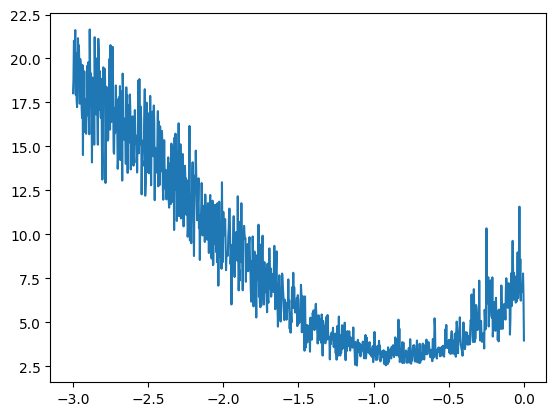

In [152]:
plt.plot(lri, lossi)
# lr이 낮아지면서 좋다가 어느정도 커지면 점점 나빠짐

In [95]:
logits.max(1)

torch.return_types.max(
values=tensor([13.4803, 18.1071, 20.7400, 20.8216, 16.9567, 13.4803, 16.2105, 14.3531,
        16.0953, 18.6156, 16.1836, 21.1566, 13.4803, 17.3798, 17.3764, 20.3180,
        13.4803, 16.8034, 15.3868, 17.3206, 18.7823, 16.2196, 11.0971, 10.8824,
        15.6571, 13.4803, 16.3803, 17.1817, 12.8921, 16.3670, 19.3423, 16.3281],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [ ]:
Y
# ... 이후로 오는 것이 데이터 셋 내에 e, o, a, i, s가 있으므로 같은 입력에 완전히 같을 수 없음. (overfit할 수 없음. loss = 0)
# unique한 input에 대해서는 왼전히 같을 수 있음 = overfit

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [ ]:
# training split(param train), dev/validation split(hyperparam train), test split(evaluate the performance of model)
# 80%, 10%, 10%